Dataset carregado:
   nome_doenca                                           sintomas
0     Diabetes             poliúria polidipsia fadiga visão turva
1  Hipertensão                  dor de cabeça tontura falta de ar
2         Asma                       tosse chiado aperto no peito
3        Gripe                 febre dor muscular congestão nasal
4    Depressão  tristeza insônia fadiga dificuldade de concent...
5      Artrite               dor articular inchaço rigidez fadiga

=== PARSING ===

Texto:
poliúria polidipsia fadiga visão turva

        token   pos
0    poliúria  NOUN
1  polidipsia   ADJ
2      fadiga  NOUN
3       visão  NOUN
4       turva   ADJ

=== EXTRAÇÃO SVO ===

Frase: O paciente relata fadiga.
Sujeito: paciente | Verbo: relatar | Objeto: fadiga

Frase: O médico diagnosticou diabetes.
Sujeito: médico | Verbo: diagnosticar | Objeto: diabetes

Frase: O sintoma causa desconforto.
Sujeito: sintoma | Verbo: causar | Objeto: desconforto

=== NER ===

Doença: Diabetes
Tokens

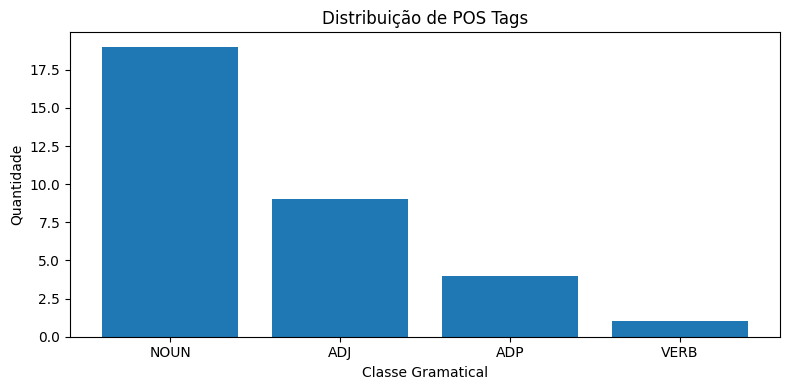

In [3]:
import pandas as pd
import spacy
import matplotlib.pyplot as plt
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# Carregar modelo spaCy
try:
    nlp = spacy.load("pt_core_news_lg")
except:
    print("python -m spacy download pt_core_news_lg")

# %% 2. DATASET
# =============================================================================

dados = {
    'nome_doenca': [
        'Diabetes',
        'Hipertensão',
        'Asma',
        'Gripe',
        'Depressão',
        'Artrite'
    ],

    'sintomas': [
        'poliúria polidipsia fadiga visão turva',
        'dor de cabeça tontura falta de ar',
        'tosse chiado aperto no peito',
        'febre dor muscular congestão nasal',
        'tristeza insônia fadiga dificuldade de concentração',
        'dor articular inchaço rigidez fadiga'
    ]
}

df = pd.DataFrame(dados)

print("Dataset carregado:")
print(df)
print()

# %% 3. PARSING SINTÁTICO
# =============================================================================

def realizar_parsing(texto):

    doc = nlp(texto)

    dados = []

    for token in doc:
        dados.append({
            'token': token.text,
            'pos': token.pos_,
            'dep': token.dep_
        })

    return pd.DataFrame(dados)


print("=== PARSING ===\n")

texto = df.loc[0, 'sintomas']

print("Texto:")
print(texto)
print()

resultado_parsing = realizar_parsing(texto)

print(resultado_parsing[['token', 'pos']])
print()

# %% 4. EXTRAÇÃO SVO
# =============================================================================

def extrair_svo(texto):

    doc = nlp(texto)

    relacoes = []

    for token in doc:

        if token.pos_ == "VERB":

            sujeito = None
            objeto = None

            for child in token.children:

                if child.dep_ == "nsubj":
                    sujeito = child.text

                if child.dep_ == "obj":
                    objeto = child.text

            if sujeito and objeto:

                relacoes.append({
                    'sujeito': sujeito,
                    'verbo': token.lemma_,
                    'objeto': objeto
                })

    return relacoes


print("=== EXTRAÇÃO SVO ===\n")

frases = [
    "O paciente relata fadiga.",
    "O médico diagnosticou diabetes.",
    "O sintoma causa desconforto."
]

for frase in frases:

    print(f"Frase: {frase}")

    svos = extrair_svo(frase)

    if svos:

        for svo in svos:

            print(
                f"Sujeito: {svo['sujeito']} | "
                f"Verbo: {svo['verbo']} | "
                f"Objeto: {svo['objeto']}"
            )

    else:
        print("Nenhuma relação encontrada")

    print()

# %% 5. NER - ENTIDADES NOMEADAS
# =============================================================================

def analisar_ner(texto):

    doc = nlp(texto)

    entidades = []

    for ent in doc.ents:

        entidades.append({
            'entidade': ent.text,
            'tipo': ent.label_
        })

    return entidades


print("=== NER ===\n")

for idx, row in df.iterrows():

    doc = nlp(row['sintomas'])

    n_tokens = len(doc)

    n_substantivos = sum(1 for t in doc if t.pos_ == "NOUN")

    print(f"Doença: {row['nome_doenca']}")
    print(f"Tokens: {n_tokens}")
    print(f"Substantivos: {n_substantivos}")

    entidades = analisar_ner(row['sintomas'])

    if entidades:

        print("Entidades:")

        for ent in entidades:
            print(f"- {ent['entidade']} ({ent['tipo']})")

    print()

# %% 6. ANÁLISE DE SENTIMENTOS
# =============================================================================

def analisar_adjetivos(texto):

    doc = nlp(texto)

    resultados = []

    for token in doc:

        if token.pos_ == "ADJ":

            resultados.append({
                'adjetivo': token.text,
                'modifica': token.head.text
            })

    return resultados


print("=== ANÁLISE DE SENTIMENTOS ===\n")

frases_sentimento = [

    "O paciente apresenta fadiga intensa.",

    "A tosse é seca e irritante.",

    "Dor articular severa e dolorosa."
]

for frase in frases_sentimento:

    print(f"Frase: {frase}")

    adjetivos = analisar_adjetivos(frase)

    for adj in adjetivos:

        print(
            f"Adjetivo: {adj['adjetivo']} "
            f"(modifica: {adj['modifica']})"
        )

    print()

# %% 7. PROCESSAMENTO DE ENTRADA DO USUÁRIO
# =============================================================================

def processar_usuario(texto):

    doc = nlp(texto)

    tokens = [

        token.lemma_.lower()

        for token in doc

        if token.pos_ in ['NOUN', 'ADJ']
        and not token.is_stop
    ]

    severidade = "MODERADA"

    if any(
        termo in texto.lower()
        for termo in ['grave', 'severo', 'intenso']
    ):
        severidade = "GRAVE"

    elif any(
        termo in texto.lower()
        for termo in ['leve', 'suave']
    ):
        severidade = "LEVE"

    return {
        'tokens': tokens,
        'severidade': severidade
    }


print("=== PROCESSAMENTO DO USUÁRIO ===\n")

exemplos = [

    "Sinto fadiga intensa e visão turva",

    "Tenho tosse leve e dor no peito",

    "Apresento dor articular severa"
]

for exemplo in exemplos:

    resultado = processar_usuario(exemplo)

    print(f"Entrada: {exemplo}")
    print(f"Tokens: {resultado['tokens']}")
    print(f"Severidade: {resultado['severidade']}")
    print()

# %% 8. VISUALIZAÇÃO
# =============================================================================

print("=== GRÁFICO ===\n")

# Contagem de POS Tags
pos_total = Counter()

for texto in df['sintomas']:

    doc = nlp(texto)

    pos_total.update([token.pos_ for token in doc])

# Gráfico
plt.figure(figsize=(8, 4))

plt.bar(
    pos_total.keys(),
    pos_total.values()
)

plt.title("Distribuição de POS Tags")

plt.xlabel("Classe Gramatical")

plt.ylabel("Quantidade")

plt.tight_layout()

plt.savefig("grafico_pos_tags.png", dpi=300)

print("Gráfico salvo: grafico_pos_tags.png")
print()

# %% 9. RESUMO FINAL
# =============================================================================

print("=== RESUMO ===\n")

print("Parsing implementado")
print("Extração SVO implementada")
print("NER implementado")
print("Análise de sentimentos implementada")
print("Processamento de sintomas do usuário")
print("Visualização gerada")